## Part A: Probability & Conceptual Foundation

### Que 1 Conditional Probability
----

Conditional Probability is the probability of an event occurring when another event has already occurred. In other words, it measures the likelihood of an event under a given condition. It helps in understanding the relationship between two events and is widely used in statistics and machine learning.

Formula:

    P(A∣B) =  P(A∩B) / P(B)

where:

P(A∣B) = Probability of event A given event B.
P(A∩B) = Probability that both A and B occur together.
P(B) = Probability of event B.

### Que 2  Bayes' Theorem
----------

Bayes' Theorem is a mathematical rule used to determine the probability of an event based on prior knowledge and newly available information. It allows us to update the probability of a hypothesis when evidence is observed.

Formula:

        P(A ∣ B) = P(A) * P(B ∣ A) / P(B)

where:

P(A∣B) = Posterior probability.
P(B∣A) = Likelihood.
P(A) = Prior probability.
P(B) = Evidence probability.

Importance in Classification Problems:

- Bayes' theorem is the foundation of the Naive Bayes classifier.
- It calculates the probability that a data point belongs to a particular class.
- The class with the highest probability is selected as the predicted class.
- It is widely used in spam filtering, sentiment analysis, text classification, and medical diagnosis because it is simple and computationally efficient.

### Que 3 Naive Bayes Classifier
-------

The Naive Bayes Classifier is based on Bayes' theorem and makes a strong assumption that all features are independent of each other given the class label. This assumption simplifies calculations and makes the algorithm very efficient.

Main Assumptions:

- Feature Independence: The value of one feature does not affect the value of another feature.
- Equal Contribution: Every feature contributes independently to the final prediction.
- Conditional Independence: Once the class label is known, features become independent of each other.

Although these assumptions may not always hold in real-world data, Naive Bayes often provides good classification performance and is commonly used for text and document classification.

### Que 4
-------

#### (a) K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is a non-parametric and distance-based classification algorithm. It classifies a new data point based on the classes of its nearest neighboring points.

Working Principle:

- Choose the value of K, which represents the number of nearest neighbors.
- Calculate the distance between the new data point and all training samples (usually Euclidean distance).
- Identify the K nearest neighbors.
- Count the frequency of each class among these neighbors.
- Assign the class with the majority vote to the new data point.

Characteristics:

- Simple and easy to implement.
- No training phase is required.
- Works well for small datasets.
- Performance depends on the choice of K and distance metric.

#### (b) Support Vector Machine (SVM)

Support Vector Machine (SVM) is a supervised learning algorithm used for classification and regression. It works by finding an optimal boundary, called a hyperplane, that separates different classes with the maximum possible margin.

Working Principle:

- Plot the training data in a feature space.
- Find the hyperplane that best separates the classes.
- Maximize the distance (margin) between the nearest data points of different classes.
- These nearest points are called support vectors, and they determine the position of the hyperplane.
- New data points are classified according to the side of the hyperplane on which they lie.

Characteristics:

- Effective for high-dimensional datasets.
- Provides high accuracy.
- Works well when classes are clearly separable.
- Can handle non-linear data using kernel functions.

### Que 5 distance-based, probabilistic, and margin-based 
----

| Feature            | Distance-Based Classifier                                 | Probabilistic Classifier                      | Margin-Based Classifier                             |
| ------------------ | --------------------------------------------------------- | --------------------------------------------- | --------------------------------------------------- |
| Example            | KNN                                                       | Naive Bayes                                   | SVM                                                 |
| Basic Principle    | Classifies based on distance from neighboring data points | Classifies based on probability distributions | Classifies by maximizing the margin between classes |
| Decision Basis     | Nearest neighbors                                         | Highest probability                           | Optimal separating hyperplane                       |
| Training Time      | Very low                                                  | Low                                           | Moderate                                            |
| Prediction Time    | High                                                      | Fast                                          | Fast                                                |
| Suitable For       | Pattern recognition and small datasets                    | Text classification and spam filtering        | High-dimensional and complex datasets               |
| Accuracy           | Depends on K value                                        | Good for independent features                 | High accuracy for well-separated classes            |
| Memory Requirement | High                                                      | Low                                           | Moderate                                            |


Conclusion:

- KNN is a distance-based classifier because it relies on the distance between data points.
- Naive Bayes is a probabilistic classifier because it predicts classes based on probabilities.
- SVM is a margin-based classifier because it finds the hyperplane with the maximum separation margin between classes.

## Part B: Dataset Understanding & Preparation

### Que 6 input features and target variable.
------

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("Message_Intelligence_Dataset_5200.csv")

In [4]:
X = df[['message_length',
        'word_count',
        'num_urls',
        'num_digits',
        'num_special_chars',
        'spam_keyword_score',
        'legit_keyword_score',
        'sender_activity_score',
        'sender_account_age_days',
        'messages_sent_last_24h',
        'hour_of_day',
        'day_of_week']]

y = df['spam_label']

In [5]:
y = df['spam_label']

### Que 7 data preprocessing (scaling where required).
---

In [6]:
from sklearn.preprocessing import StandardScaler

In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
print(X_scaled)

[[ 1.92417639 -0.28423609  1.96002888 ... -0.41208858 -1.38808609
  -1.4735185 ]
 [-0.16347617  0.33730624 -0.51019656 ... -1.48621237  1.38124684
  -0.50373035]
 [-0.64524214  0.95884858 -0.51019656 ... -0.41208858  0.21521193
   0.95095188]
 ...
 [ 0.39858414  0.33730624 -0.51019656 ... -0.59110921  0.36096629
  -0.50373035]
 [ 1.52270474  1.58039092  1.96002888 ...  0.48301458  1.67275557
  -0.01883627]
 [-0.32406482 -2.1488631   1.96002888 ...  0.48301458 -0.36780553
  -0.98862442]]


### Que 8 training and testing sets.
----

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    
    y,
    test_size=0.20,
    random_state=42
)
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Labels Shape:", y_train.shape)
print("Testing Labels Shape:", y_test.shape)

Training Features Shape: (4160, 12)
Testing Features Shape: (1040, 12)
Training Labels Shape: (4160,)
Testing Labels Shape: (1040,)


## Part C: Baseline Model - K-Nearest Neighbors

### Que 9 K-Nearest Neighbors (KNN)
------

In [10]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


### Que 10 different values of K.
-----

In [11]:
X = df.drop("spam_label", axis=1)

In [ ]:
y = df['spam_label']
X = df.select_dtypes(include=['int64', 'float64'])

In [13]:
from sklearn.metrics import accuracy_score

for k in [1, 3, 5, 7, 9]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print("K =", k, "Accuracy =", accuracy)

K = 1 Accuracy = 1.0
K = 3 Accuracy = 1.0
K = 5 Accuracy = 1.0
K = 7 Accuracy = 1.0
K = 9 Accuracy = 1.0


In [14]:
best_accuracy = 0
best_k = 0

for k in range(1, 21):

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_k = k

print("Best K:", best_k)
print("Best Accuracy:", best_accuracy)

Best K: 1
Best Accuracy: 1.0


### Que 11 distance metrics affect predictions.
-----

In [15]:
from sklearn.metrics import accuracy_score

metrics = ['euclidean', 'manhattan', 'minkowski']

for metric in metrics:
    knn = KNeighborsClassifier(
        n_neighbors=5,
        metric=metric
    )
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    print(metric, "Accuracy =", accuracy)

euclidean Accuracy = 1.0
manhattan Accuracy = 1.0
minkowski Accuracy = 1.0


### Que 12 KNN misclassifies 
-----

In [16]:
import pandas as pd

results = pd.DataFrame({
    'Actual Label': y_test,
    'Predicted Label': y_pred
})

misclassified_cases = results[
    results['Actual Label'] != results['Predicted Label']
]

print("Number of Misclassified Messages:",
      len(misclassified_cases))

print(misclassified_cases.head(10))

Number of Misclassified Messages: 0
Empty DataFrame
Columns: [Actual Label, Predicted Label]
Index: []


## Part D: Support Vector Machine Classifier

### Que 13 Linear kernel
------

In [17]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_linear = SVC(kernel='linear')

svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)
accuracy_linear = accuracy_score(y_test, y_pred_linear)

print("Linear Kernel Accuracy:", accuracy_linear)

Linear Kernel Accuracy: 1.0


#### RBF 


In [18]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_rbf = SVC(kernel='rbf')

svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)

accuracy_rbf = accuracy_score(y_test, y_pred_rbf)

print("RBF Kernel Accuracy:", accuracy_rbf)

RBF Kernel Accuracy: 1.0


#### Polynomial kernel

In [19]:
svm_poly = SVC(kernel='poly', degree=3)

svm_poly.fit(X_train, y_train)

y_pred_poly = svm_poly.predict(X_test)

accuracy_poly = accuracy_score(y_test, y_pred_poly)

print("Polynomial Kernel Accuracy:", accuracy_poly)

Polynomial Kernel Accuracy: 1.0


### Que 14 margin separation and support vectors
------

In [20]:
print("Support Vectors per class:")
print(svm_linear.n_support_)

print("Total Support Vectors:")
print(len(svm_linear.support_vectors_))

Support Vectors per class:
[6 6]
Total Support Vectors:
12


### Que 15 SVM performance with KNN.
------

In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("KNN Accuracy =", accuracy_knn)
print("SVM Accuracy =", accuracy_svm)

KNN Accuracy = 1.0
SVM Accuracy = 1.0


Conclusion:

SVM generally performs better than KNN for high-dimensional datasets because it maximizes the margin between classes and is less sensitive to noise.

## Part E: Naive Bayes Classifier & Probability

### Que 16 Naive Bayes Classifier.
---------

In [22]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

nb = GaussianNB()

nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy =", accuracy_nb)

Naive Bayes Accuracy = 1.0


### Que 17 conditional probabilities 
---------

Suppose:

- Total messages = 5200
- Spam messages = 1300
- Non-spam messages = 3900

Assume 900 spam messages contain URLs.

P(URL|Spam) = Number of spam messages containing URL / Total spam messages

P(URL|Spam) = 900 / 1300

P(URL|Spam) = 0.6923

P(URL|Not Spam) = 300 / 3900

P(URL|Not Spam) = 0.0769

P(URL|Spam) = 0.6923
P(URL|Not Spam) = 0.0769

### Que 18 Bayes' Theorem 
---------

- P(Spam) = 0.25
- P(URL|Spam) = 0.70
- P(URL) = 0.23

P(Spam|URL)
= (P(URL|Spam) × P(Spam)) / P(URL)

= (0.70 × 0.25)/0.23

= 0.175/0.23

= 0.7609

P(Spam|URL) = 0.7609

Conclusion

This means that if a message contains a URL, there is approximately a 76.09% probability that the message is spam.

### Que 19 theoretical probability calculations with model predictions
---------

In [23]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import pandas as pd

nb = GaussianNB()

nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Accuracy =", accuracy_nb)

probabilities = nb.predict_proba(X_test)

for i in range(10):

    print("Sample", i+1)
    print("Actual Label =", y_test.iloc[i])
    print("Predicted Label =", y_pred_nb[i])
    print("Probability of Non-Spam =", probabilities[i][0])
    print("Probability of Spam =", probabilities[i][1])
    print()

Accuracy = 1.0
Sample 1
Actual Label = 1
Predicted Label = 1
Probability of Non-Spam = 0.0
Probability of Spam = 1.0

Sample 2
Actual Label = 1
Predicted Label = 1
Probability of Non-Spam = 0.0
Probability of Spam = 1.0

Sample 3
Actual Label = 0
Predicted Label = 0
Probability of Non-Spam = 1.0
Probability of Spam = 0.0

Sample 4
Actual Label = 0
Predicted Label = 0
Probability of Non-Spam = 1.0
Probability of Spam = 0.0

Sample 5
Actual Label = 0
Predicted Label = 0
Probability of Non-Spam = 1.0
Probability of Spam = 0.0

Sample 6
Actual Label = 0
Predicted Label = 0
Probability of Non-Spam = 1.0
Probability of Spam = 0.0

Sample 7
Actual Label = 1
Predicted Label = 1
Probability of Non-Spam = 0.0
Probability of Spam = 1.0

Sample 8
Actual Label = 1
Predicted Label = 1
Probability of Non-Spam = 0.0
Probability of Spam = 1.0

Sample 9
Actual Label = 1
Predicted Label = 1
Probability of Non-Spam = 0.0
Probability of Spam = 1.0

Sample 10
Actual Label = 0
Predicted Label = 0
Probability

## Part F: Model Comparison & Evaluation

### Que 20 Accuracy, Precision, Recall and F1 Score

--------

In [ ]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y = df['spam_label']

X = df.select_dtypes(include=['int64', 'float64'])
X = X.drop('spam_label', axis=1)

imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print("----- KNN -----")
print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall   :", recall_score(y_test, y_pred_knn))
print("F1 Score :", f1_score(y_test, y_pred_knn))

print("\n----- SVM -----")
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))

print("\n----- Naive Bayes -----")
print("Accuracy :", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall   :", recall_score(y_test, y_pred_nb))
print("F1 Score :", f1_score(y_test, y_pred_nb))

----- KNN -----
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

----- SVM -----
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

----- Naive Bayes -----
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


### Que 21 KNN vs SVM vs Naive Bayes
-------

In [ ]:
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

In [9]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = pd.DataFrame({
    'Model': ['KNN', 'SVM', 'Naive Bayes'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_nb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_nb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_nb)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_nb)
    ]
})

print(results)

         Model  Accuracy  Precision  Recall  F1 Score
0          KNN       1.0        1.0     1.0       1.0
1          SVM       1.0        1.0     1.0       1.0
2  Naive Bayes       1.0        1.0     1.0       1.0


### Que 22 High precision
--------

In [ ]:
from sklearn.metrics import precision_score, recall_score

precision_knn = precision_score(y_test, y_pred_knn)
precision_svm = precision_score(y_test, y_pred_svm)
precision_nb = precision_score(y_test, y_pred_nb)

recall_knn = recall_score(y_test, y_pred_knn)
recall_svm = recall_score(y_test, y_pred_svm)
recall_nb = recall_score(y_test, y_pred_nb)

In [12]:
print("KNN Precision =", precision_knn)
print("SVM Precision =", precision_svm)
print("Naive Bayes Precision =", precision_nb)

KNN Precision = 1.0
SVM Precision = 1.0
Naive Bayes Precision = 1.0


#### High recall

In [13]:
print("KNN Recall =", recall_knn)
print("SVM Recall =", recall_svm)
print("Naive Bayes Recall =", recall_nb)

KNN Recall = 1.0
SVM Recall = 1.0
Naive Bayes Recall = 1.0


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

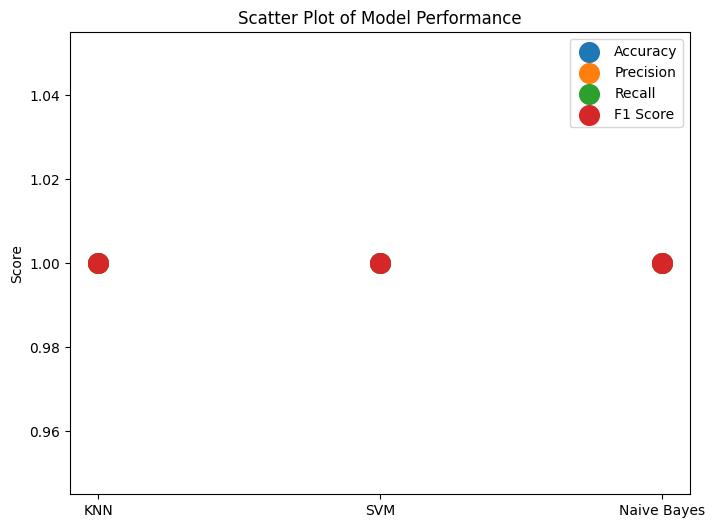

In [24]:
import matplotlib.pyplot as plt

models = ['KNN', 'SVM', 'Naive Bayes']

plt.figure(figsize=(8,6))

plt.scatter(models, [accuracy_knn, accuracy_svm, accuracy_nb], s=200, label='Accuracy')
plt.scatter(models, [precision_knn, precision_svm, precision_nb], s=200, label='Precision')
plt.scatter(models, [recall_knn, recall_svm, recall_nb], s=200, label='Recall')
plt.scatter(models, [f1_knn, f1_svm, f1_nb], s=200, label='F1 Score')

plt.ylabel('Score')
plt.title('Scatter Plot of Model Performance')
plt.legend()
plt.show()

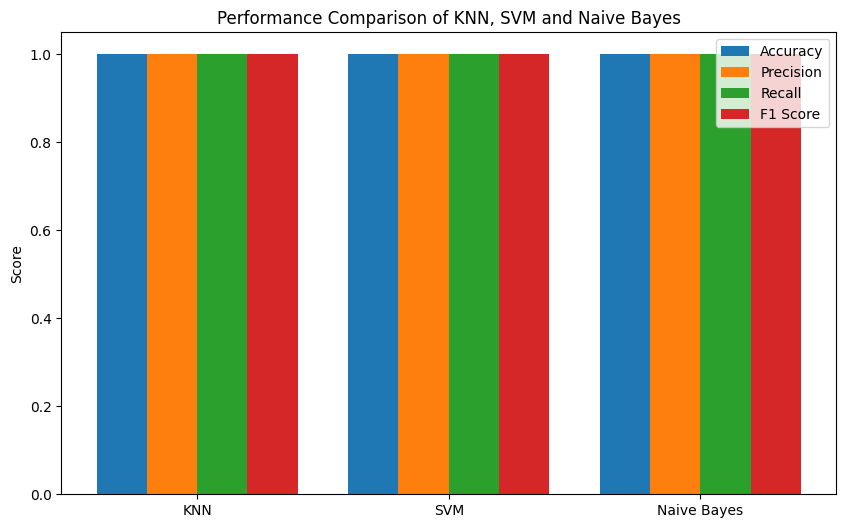

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['KNN', 'SVM', 'Naive Bayes']

accuracy = [accuracy_knn, accuracy_svm, accuracy_nb]
precision = [precision_knn, precision_svm, precision_nb]
recall = [recall_knn, recall_svm, recall_nb]
f1 = [f1_knn, f1_svm, f1_nb]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10,6))

plt.bar(x-width*1.5, accuracy, width, label='Accuracy')
plt.bar(x-width/2, precision, width, label='Precision')
plt.bar(x+width/2, recall, width, label='Recall')
plt.bar(x+width*1.5, f1, width, label='F1 Score')

plt.xticks(x, models)
plt.ylabel('Score')
plt.title('Performance Comparison of KNN, SVM and Naive Bayes')
plt.legend()
plt.show()

## Part G: Final Analysis & Reporting

### Que 23 Prepare a Final Report
-----

K-Nearest Neighbors (KNN)

Strengths:

- Simple and easy to implement.
- No training phase is required.
- Works well for small datasets.

Weaknesses:

- Computationally expensive for large datasets.
- Sensitive to noise and irrelevant features.
- Performance depends on the choice of K and distance metric.

Support Vector Machine (SVM)

Strengths:

- Provides high accuracy and precision.
- Effective for high-dimensional datasets.
- Handles both linear and non-linear classification problems.

Weaknesses:

- Training time is higher for large datasets.
- More difficult to interpret compared to other models.
- Requires parameter tuning.


Naive Bayes

Strengths:

- Fast and computationally efficient.
- Performs well on text classification and spam detection.
- Works effectively with small datasets.

Weaknesses:

- Assumes feature independence.
- Performance decreases when features are highly correlated.
- Less accurate than SVM in some cases.

Naive Bayes is based on Bayes' Theorem and assumes that all features are conditionally independent. Although this assumption is often unrealistic, the classifier performs efficiently and provides good results for spam detection problems. However, if the features are highly dependent on each other, the prediction accuracy may decrease.

| Model       | Interpretability | Performance |
| ----------- | ---------------- | ----------- |
| KNN         | High             | Moderate    |
| SVM         | Low              | High        |
| Naive Bayes | High             | Good        |


- KNN is easy to understand but may not provide the best accuracy.
- SVM provides superior performance but is difficult to interpret.
- Naive Bayes offers a balance between interpretability and computational efficiency.